# 4. Прилив
Прилив идёт из океана вверх по реке Делавэр. Датчики: 8 станций вдоль реки, уровень воды каждые 6 минут, январь и февраль 2024 года ([NOAA](https://tidesandcurrents.noaa.gov/)).

Прилив складывается из приливных волн, синусоид с известными периодами:
- $M_2$: главная лунная, 12.42 ч;
- $S_2$: главная солнечная, 12 ч;
- $N_2$: лунная, от вытянутости орбиты Луны, 12.66 ч;
- $K_1$: суточная, от Луны и Солнца, 23.93 ч;
- $O_1$: лунная суточная, 25.82 ч;
- $M_4$: мелководная, 6.21 ч, половина периода $M_2$; возникает, когда прилив искажается на мелководье.

NOAA даёт амплитуду и фазу каждой волны на каждой станции.

Расстояние от устья считаем по прямым между соседними станциями; до верхней станции 196 км.

In [1]:
import sys, warnings
import numpy as np, matplotlib.pyplot as plt
import plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
from scipy.signal import find_peaks
warnings.filterwarnings("ignore")
sys.path.insert(0, "../synthetic")
from torus import pca, spectrum, with_delay
from models import basis
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.titlesize": 11, "axes.spines.top": False, "axes.spines.right": False})
pio.renderers.default = "plotly_mimetype+notebook_connected"

d = np.load("../real/data/tides.npz")
km, harcon = d["distance_km"], d["harcon"]  # станция, волна (M2, S2, N2, K1, O1, M4), величина (амплитуда, фаза, скорость)
names = ["Льюис", "Брандивайн Шол", "Шип Джон Шол", "Риди Пойнт", "Маркус Хук", "Филадельфия", "Берлингтон", "Ньюболд"]
t, eta = d["t"][::10], d["eta"][:, ::10]
jan = 31 * 24
eta = eta - eta[:, :jan].mean(1, keepdims=True)
nu = harcon[0, :, 2] / 360

In [2]:
lat, lng = d["lat"], d["lng"]
label = [f"{s}<br>{k:.0f} км" for s, k in zip(names, km)]
font = dict(size=12, color="black", family="Open Sans Semibold")
fig = go.Figure()
fig.add_trace(go.Scattermap(lat=[38.56, lat[0]], lon=[-74.91, lng[0]], mode="lines", line=dict(color="#d62728", width=3), hoverinfo="skip"))
fig.add_trace(go.Scattermap(lat=[38.62], lon=[-74.6], mode="text", text=["прилив из океана"], textfont=font | dict(color="#d62728"), hoverinfo="skip"))
fig.add_trace(go.Scattermap(lat=lat, lon=lng, mode="lines", line=dict(color="gray", width=1.5), hoverinfo="skip"))
for idx, pos in [([0, 1, 2, 3, 4, 5, 7], "middle right"), ([6], "middle left")]:
    fig.add_trace(go.Scattermap(
        lat=lat[idx], lon=lng[idx], mode="markers+text", text=[label[i] for i in idx], textposition=pos, textfont=font,
        marker=dict(size=10, color="black"), customdata=harcon[idx, 0, :2],
        hovertemplate="<b>%{text}</b><br>амплитуда M2: %{customdata[0]:.2f} м<br>фаза M2: %{customdata[1]:.0f}°<extra></extra>"))
fig.update_layout(map=dict(style="carto-positron-nolabels", center=dict(lat=39.36, lon=-75.0), zoom=7.2),
                  height=520, width=620, margin=dict(l=0, r=0, t=40, b=0), showlegend=False,
                  title="Станции NOAA: расстояние от устья по ломаной")
fig.show()

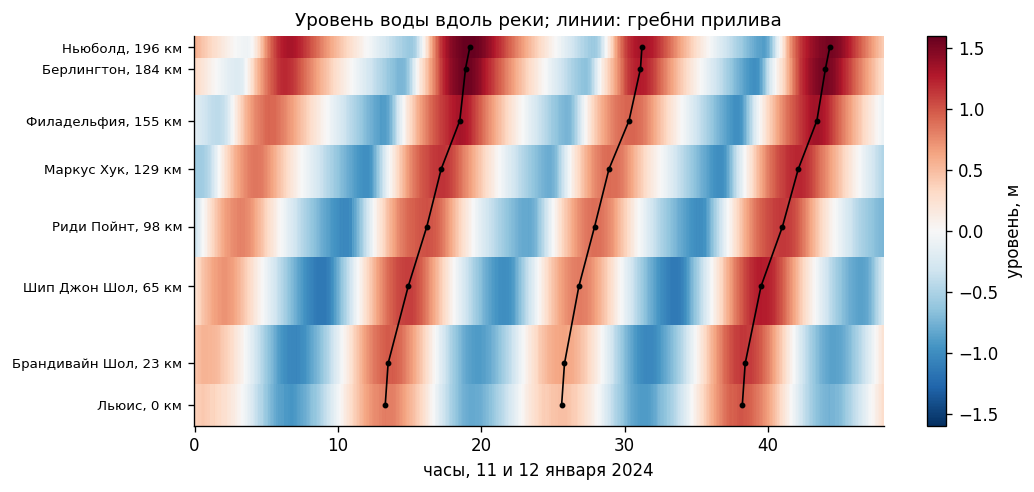

In [3]:
win = (d["t"] >= 10 * 24) & (d["t"] <= 12 * 24)
hours = d["t"][win] - 10 * 24
level = (d["eta"] - d["eta"][:, :jan * 10].mean(1, keepdims=True))[:, win]
lim = np.abs(level).max()
fig, ax = plt.subplots(figsize=(9, 4.2))
im = ax.pcolormesh(hours, km, level, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="nearest")
crests = [hours[find_peaks(e, distance=80, prominence=0.3)[0]] for e in level]
for c in crests[0]:
    path = [c]
    for nxt in crests[1:]:
        later = nxt[(nxt >= path[-1]) & (nxt <= path[-1] + 3)]
        if not len(later):
            break
        path.append(later[0])
    ax.plot(path, km[:len(path)], "k.-", lw=1, ms=5)
ax.set_yticks(km, [f"{s}, {k:.0f} км" for s, k in zip(names, km)], fontsize=8)
ax.set(xlabel="часы, 11 и 12 января 2024", title="Уровень воды вдоль реки; линии: гребни прилива")
fig.colorbar(im, ax=ax, label="уровень, м")
plt.tight_layout()

### Как прилив идёт вверх по реке
На каждой станции волна $M_2$ - $A\cos(360^\circ\,t/T+V-\varphi)$ с периодом $T=12.42$ ч; сдвиг $V$ зависит только от начала отсчёта времени и одинаков для всех станций. Поэтому разность фаз $\varphi$ двух станций есть запаздывание в градусах: $360^\circ$ соответствует целому периоду, $1^\circ=T/360\approx2$ мин.
- Сверху: фаза $M_2$ вдоль реки. Чем дальше от устья, тем позже приходит полная вода. Если фаза растёт на $k$ градусов на км, скорость прилива $c=360/(kT)$.
- Снизу: отношение амплитуд $M_4/M_2$, мера искажения прилива.

In [4]:
phase = harcon[:, 0, 1]
slope, icpt = np.polyfit(km, phase, 1)
seg = 360 * nu[0] * np.diff(km) / np.diff(phase)
ratio = harcon[:, 5, 0] / harcon[:, 0, 0]
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08)
fig.add_trace(go.Scatter(x=km, y=icpt + slope * km, mode="lines", line=dict(color="gray", dash="dash", width=1),
                         name=f"наклон {slope:.2f} град/км", hoverinfo="skip"), 1, 1)
for row, val, fmt in [(1, phase, "фаза M2: %{y:.0f}°"), (2, ratio, "M4 / M2: %{y:.3f}")]:
    fig.add_trace(go.Scatter(x=km, y=val, mode="lines+markers", line=dict(color="#1f77b4", width=2), marker=dict(size=8),
                             text=names, showlegend=False,
                             hovertemplate="<b>%{text}</b>, %{x:.0f} км<br>" + fmt + "<extra></extra>"), row, 1)
fig.update_yaxes(title_text="фаза M2, град", row=1, col=1)
fig.update_yaxes(title_text="амплитуда M4 / M2", rangemode="tozero", row=2, col=1)
fig.update_xaxes(title_text="расстояние от устья, км", row=2, col=1)
fig.update_layout(template="plotly_white", height=520, width=720, margin=dict(l=70, r=20, t=20, b=50),
                  legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"))
fig.show()
print(f"фаза M2 растёт в среднем на {slope:.2f} град/км; средняя скорость около {360 * nu[0] / slope:.0f} км/ч")
print(f"скорость по участкам между станциями: от {seg.min():.0f} до {seg.max():.0f} км/ч")
print(f"M4/M2: {ratio[0]:.3f} у устья, {ratio[-1]:.3f} у верхней станции")

фаза M2 растёт в среднем на 1.03 град/км; средняя скорость около 28 км/ч
скорость по участкам между станциями: от 20 до 106 км/ч
M4/M2: 0.019 у устья, 0.138 у верхней станции


- Фаза $M_2$ растёт вверх по реке в среднем на $1.03^\circ$ на км: прилив идёт от океана со средней скоростью около 28 км/ч, на отдельных участках от 20 до 106 км/ч.
- Отношение $M_4/M_2$ в целом растёт вверх по реке, от 0.019 у устья до 0.138 у верхней станции, но не монотонно: выше по реке волна искажается сильнее.

## Фазовое пространство
Точка фазового пространства составлена из уровней воды $\eta_i(t)$ на станциях $i=1,\dots,8$ в моменты $t$ и $t-\tau$; отсчёты берём раз в час:
$$X(t)=\bigl(\eta_1(t),\dots,\eta_8(t),\ \eta_1(t-\tau),\dots,\eta_8(t-\tau)\bigr)\in\mathbb R^{16},\qquad \tau=3\ \text{ч}.$$
Ниже показаны проекция траектории $X(t)$ на три главные оси (цвет показывает четвёртую ось) и сингулярные числа облака точек, делённые на наибольшее. Для сравнения взят чистый прилив: сумма шести волн с частотами NOAA, подогнанная к записи.

In [5]:
X = with_delay(eta, 3)
P = pca(X)
span = 20 * 24
hide = dict(showticklabels=False, showspikes=False)
fig = go.Figure(go.Scatter3d(x=P[:span, 0], y=P[:span, 1], z=P[:span, 2], mode="lines", customdata=t[3:span + 3] / 24,
                             line=dict(width=3, color=P[:span, 3], colorscale="Plasma", colorbar=dict(title="ось 4", thickness=12, len=0.6)),
                             hovertemplate="сутки %{customdata:.2f}<extra></extra>"))
fig.update_scenes(xaxis=dict(title="ось 1", **hide), yaxis=dict(title="ось 2", **hide), zaxis=dict(title="ось 3", **hide), aspectmode="data")
fig.update_layout(template="plotly_white", height=480, margin=dict(l=10, r=10, t=40, b=10), title="Проекция траектории на три главные оси, первые 20 суток")
fig.show()

запись:     1.00 0.96 0.46 0.15 0.10 0.08
чистый прилив: 1.00 0.98 0.15 0.12 0.06 0.03


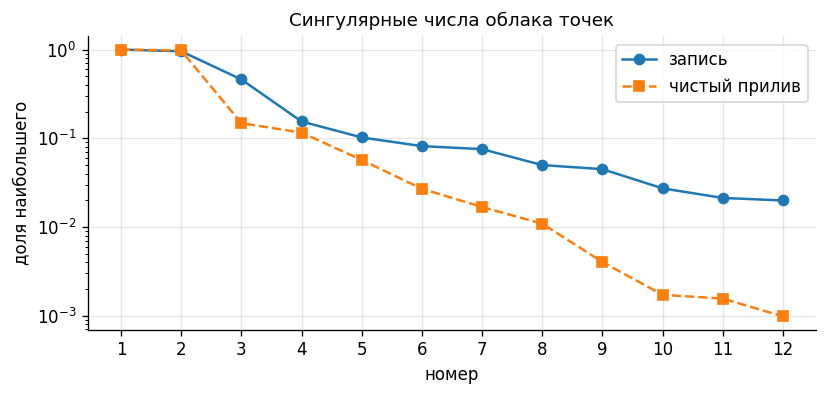

In [6]:
B = basis(t, nu)
fit = (B @ np.linalg.lstsq(B, eta.T, rcond=None)[0]).T
s_rec, s_fit = spectrum(X)[:12], spectrum(with_delay(fit, 3))[:12]
k = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.semilogy(k, s_rec, "o-", label="запись")
ax.semilogy(k, s_fit, "s--", label="чистый прилив")
ax.set(xticks=k, xlabel="номер", ylabel="доля наибольшего", title="Сингулярные числа облака точек")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
print("запись:    ", " ".join(f"{v:.2f}" for v in s_rec[:6]))
print("чистый прилив:", " ".join(f"{v:.2f}" for v in s_fit[:6]))

## Итог
- Прилив идёт вверх по реке со скоростью около 28 км/ч.
- Выше по реке волна искажается сильнее.
- Два первых сингулярных числа даёт $M_2$.
- У записи третье сингулярное число 0.46 даёт остаток вне шести волн NOAA.